In [13]:
import os
import glob
import json
import pprint
import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm
from datasets import load_dataset

from pyperf.utils.patch_parser import SimplePatchParser
from pyperf.harness.utils import natural_sort_key
from pyperf.constants import SUBMISSIONS_DIR, PLOTS_DIR
from pyperf.harness.scripts.helpers import *

pd.set_option("future.no_silent_downcasting", True)
pp = pprint.PrettyPrinter(indent=2)
setup_plot_style()

In [14]:
HOME_DIR = Path(os.path.expanduser("~"))
EVAL_REPORTS_DIR = HOME_DIR / "pyperf/reports"

In [15]:
def get_traces(pattern: str):
    traces = list(SUBMISSIONS_DIR.glob(pattern))
    if traces == []:
        print(f"Could not find any traces matching pattern: {pattern}")
    traces = sorted([str(t) for t in traces], key=natural_sort_key)
    return [Path(t) for t in traces]


def load_json(fname):
    with open(fname, "r") as f:
        return json.load(f)


def get_model_config(model_alias: str):
    if model_alias == "claude" or model_alias == "claude-3.6":
        model = "claude-3-5-sonnet-v2-20241022"
        beat_k = 10
    elif model_alias == "o4-mini":
        model = "o4-mini"
        beat_k = 10
    else:
        raise ValueError(f"Unknown model alias: {model_alias}")

    run_id_range = [0, beat_k]
    return model, beat_k, run_id_range


def load_evaluation_data(model_alias: str, beat_k: int, model: str):
    eval_report = (
        EVAL_REPORTS_DIR
        / "beat_k_reports"
        / f"{model_alias}.beat@{beat_k}.scale.report.json"
    )
    report = load_json(eval_report)
    traces = get_traces(
        f"manishs__pyperf-test/CodeActAgent/scale/{model}_maxiter_100_N_v0.35.0-no-hint-run_*/output.jsonl"
    )
    submissions = get_traces(
        f"manishs__pyperf-test/CodeActAgent/scale/{model}_maxiter_100_N_v0.35.0-no-hint-run_*/output.pyperf.jsonl"
    )
    return report, traces, submissions

#### Collect Dataset

In [16]:
dataset = load_dataset("manishs/pyperf-extended", split="test")
print(f"Filtered dataset size: {len(dataset)}")

Filtered dataset size: 105


#### Collect Submissions

In [17]:
def load_traces_to_df(trace_files, run_id_range):
    traces_data = []

    for trace_file in tqdm(trace_files, desc="Loading trace files"):
        run_id = trace_file.parent.name  # Extract run ID from path

        run_id_num = int(run_id.split("_")[-1])
        if run_id_num < run_id_range[0] or run_id_num > run_id_range[1]:
            continue

        with open(trace_file, "r") as f:
            for line in f:
                try:
                    trace = json.loads(line)
                    if "instance_id" in trace:
                        trace["run_id"] = run_id
                        traces_data.append(trace)
                except json.JSONDecodeError:
                    continue

    traces_df = pd.DataFrame(traces_data)

    # Print info about the dataframe
    print(f"Loaded {len(traces_df)} trace entries")
    print(f"Unique instance IDs: {traces_df['instance_id'].nunique()}")
    print(f"Unique run IDs: {traces_df['run_id'].nunique()}")

    return traces_df

#### Collect Evaluations

In [18]:
def load_opt_stats_data(report, run_id_range):
    opt_stats = report["opt_stats"]
    opt_stats_data = []

    for instance_id, stats in opt_stats.items():
        run_id = stats["report_file"].split("/")[-1].rstrip("scale.report.json")
        run_id_num = int(run_id.split("_")[-1])
        if run_id_num < run_id_range[0] or run_id_num > run_id_range[1]:
            continue

        possible_reports = list(EVAL_REPORTS_DIR.glob(f"*{run_id}.scale.report.json"))
        if not possible_reports:
            continue

        report_path = possible_reports[0]
        with open(report_path, "r") as report_file:
            report_data = json.load(report_file)

        beat_commit = instance_id in report_data.get("instance_sets", {}).get(
            "beat_commit_ids", []
        )
        stats_dict = {
            "instance_id": instance_id,
            "run_id": run_id,
            "beat_commit": beat_commit,
            **stats,
        }
        opt_stats_data.append(stats_dict)

    # Convert to DataFrame
    opt_stats_df = pd.DataFrame(opt_stats_data)
    print(f"Loaded {len(opt_stats_df)} entries from opt_stats")

    return opt_stats_df

#### Merge

In [19]:
def merge_dataframes(traces_df, opt_stats_df, dataset):
    # Sort the traces dataframe
    traces_df = traces_df.sort_values(["instance_id", "run_id"])
    dataset_df = pd.DataFrame(dataset)

    # drop rows with instance_id not in dataset_df
    traces_df = traces_df[traces_df["instance_id"].isin(dataset_df["instance_id"])]
    opt_stats_df = opt_stats_df[
        opt_stats_df["instance_id"].isin(dataset_df["instance_id"])
    ]

    merged_df = pd.merge(
        traces_df,
        opt_stats_df,
        on=["instance_id", "run_id"],
        how="outer",
        suffixes=("_trace", "_stats"),
    )
    merged_df = pd.merge(
        merged_df,
        dataset_df,
        on="instance_id",
        how="outer",
        suffixes=("_merged", "_dataset"),
    )

    merged_df.fillna({"beat_commit": False}, inplace=True)

    print(f"Merged dataframe has {len(merged_df)} rows")
    print(f"Merged dataframe has {len(merged_df.columns)} columns")
    print(
        f"Instances with both trace and stats: {merged_df.dropna(subset=['instance_id', 'run_id']).shape[0]}"
    )

    return merged_df

#### Data Helpers

In [20]:
def get_diff_stats(patch, prefix=""):
    parser = SimplePatchParser()
    diff = parser.parse_patch(patch, old_commit_hash="")
    stats = {
        f"{prefix}num_files": diff.num_non_test_files,
        f"{prefix}num_hunks": diff.num_hunks,  # note: includes test files?
        f"{prefix}num_edited_lines": diff.num_non_test_edited_lines,
        f"{prefix}files_changed": [
            file_diff.path
            for file_diff in diff.file_diffs
            if file_diff.is_test_file is False
        ],
    }

    # remove any files starting with .venv or .git
    stats[f"{prefix}files_changed"] = [
        file
        for file in stats[f"{prefix}files_changed"]
        if not file.startswith((".venv", ".git"))
    ]

    stats[f"{prefix}extensions"] = extensions_from_filenames(
        stats[f"{prefix}files_changed"]
    )

    # update files_changed to only include good extensions
    stats[f"{prefix}files_changed"] = [
        file
        for file in stats[f"{prefix}files_changed"]
        if file.split(".")[-1] in stats[f"{prefix}extensions"]
    ]
    stats[f"{prefix}num_files"] = len(stats[f"{prefix}files_changed"])

    return stats


def extensions_from_filenames(files):
    ignore_list = {
        "rst",
        "txt",
        "json",
        "md",
        "csv",
        "pkl",
        "yaml",
        "yml",
        "mdx",
        "tif",
        "tiff",
        "png",
        "jpg",
        "jpeg",
        "gif",
        "webp",
        "bmp",
        "ico",
        "svg",
        "pdf",
        "gitignore",
        "lock",
        "zip",
        "tar",
        "gz",
        "bz2",
        "xz",
        "toml",
        "npy",
        "tmpl",
        "html",
        "build",
        "venv/lib64",
        "cfg",
        "patch",
        "numpy/_core/src/npysort/x86-simd-sort",
        "numpy/core/src/npysort/x86-simd-sort",
        "Makefile",
        "ipynb",
        "ini",
        "fli",
    }
    extensions = {file.split(".")[-1] for file in files}
    return extensions - ignore_list

In [21]:
def get_agent_messages(history_list):
    if not history_list:
        return []

    return [
        {
            "id": item.get("id"),
            "message": item.get("message", ""),
            "timestamp": item.get("timestamp"),
        }
        for item in history_list
        if item.get("source") == "agent" and item.get("message")
    ]


def get_user_messages(history_list):
    if not history_list:
        return []

    return [
        {
            "id": item.get("id"),
            "message": item.get("message", ""),
            "timestamp": item.get("timestamp"),
        }
        for item in history_list
        if item.get("source") == "user" and item.get("message")
    ]


def get_tool_calls(history_list):
    if not history_list:
        return []

    tool_calls = []
    for item in history_list:
        if item.get("tool_call_metadata") and item.get("action"):
            try:
                metadata = item["tool_call_metadata"]
                function_name = metadata.get("function_name", "")
                tool_call_id = metadata.get("tool_call_id", "")
                step_id = item.get("id")

                # Extract command arguments if available
                arguments = None
                if (
                    metadata.get("model_response")
                    and metadata["model_response"].get("choices")
                    and metadata["model_response"]["choices"][0].get("message")
                    and metadata["model_response"]["choices"][0]["message"].get(
                        "tool_calls"
                    )
                ):

                    tool_call = metadata["model_response"]["choices"][0]["message"][
                        "tool_calls"
                    ][0]
                    if tool_call.get("function") and tool_call["function"].get(
                        "arguments"
                    ):
                        try:
                            arguments = json.loads(tool_call["function"]["arguments"])
                        except:
                            arguments = tool_call["function"]["arguments"]

                tool_calls.append(
                    {
                        "step_id": step_id,
                        "function_name": function_name,
                        "arguments": arguments,
                        "action": item.get("action"),
                    }
                )
            except Exception as e:
                # Skip tool calls that can't be parsed
                pass

    return tool_calls


def get_observations(history_list):
    if not history_list:
        return []

    observations = []
    for item in history_list:
        if not item.get("action") and item.get("cause"):
            observations.append(
                {
                    "id": item.get("id"),
                    "cause_id": item.get(
                        "cause"
                    ),  # Step ID that caused this observation
                    "message": item.get("message", ""),
                    "content": item.get("content", ""),
                    "error": item.get("error", ""),
                    "timestamp": item.get("timestamp"),
                    "success": item.get(
                        "success", True
                    ),  # Assume success unless explicitly marked as failed
                }
            )

    return observations


def get_action_sequence(history_list):
    if not history_list:
        return []

    return [
        {
            "step_id": item.get("id"),
            "action": item.get("action"),
            "timestamp": item.get("timestamp"),
            "source": item.get("source"),
        }
        for item in history_list
        if item.get("action")
    ]


def get_rebuilds(history_list):
    tool_calls = get_tool_calls(history_list)
    rebuilds = []
    for tool_call in tool_calls:
        if tool_call.get("arguments") and tool_call["arguments"].get("command"):
            command = tool_call["arguments"]["command"]
            if "pip install" in command:
                rebuilds.append(tool_call)
    return rebuilds


############# Counter functions #############
def get_step_counts(history_list):
    if not history_list:
        return 0

    return sum(1 for item in history_list if item.get("action"))


def get_action_counts(history_list):
    if not history_list:
        return {}

    action_counts = {}
    for item in history_list:
        action = item.get("action")
        if action:
            if action in action_counts:
                action_counts[action] += 1
            else:
                action_counts[action] = 1

    return action_counts


def get_conversation_summary(history):
    step_count = get_step_counts(history)
    action_counts = get_action_counts(history)
    rebuild_count = len(get_rebuilds(history))
    is_finished = action_counts.get("finish", 0) == 1

    return {
        "step_count": step_count,
        "action_counts": action_counts,
        "rebuild_count": rebuild_count,
        "is_finished": is_finished,
    }


def extract_per_test_times(per_test_means):
    if not per_test_means or (pd.isna(per_test_means)):
        return {
            "base_times": [],
            "patch_times": [],
            "commit_times": [],
            # "main_times": [],
        }
    return {
        f"{key}_times": value
        for key, value in per_test_means.items()
        if key in ["base", "patch", "commit"]
    }


def extract_per_test_speedups(per_test_means):
    if not per_test_means or pd.isna(per_test_means):
        return {
            f"{a}_{b}_speedups": []
            for a, b in [
                ("patch", "base"),
                ("commit", "base"),
                # ("main", "base"),
                ("patch", "commit"),
            ]
        }

    # Simple list comprehensions for each type of speedup
    result = {}

    # Calculate speedups with safe division
    result["patch_base_speedups"] = [
        b / p if p > 0 else float("inf")
        for b, p in zip(per_test_means["base"], per_test_means["patch"])
        if b > 0
    ]

    result["commit_base_speedups"] = [
        b / c if c > 0 else float("inf")
        for b, c in zip(per_test_means["base"], per_test_means["commit"])
        if b > 0
    ]

    # result["main_base_speedups"] = [
    #     b / m if m > 0 else float("inf")
    #     for b, m in zip(per_test_means["base"], per_test_means["main"])
    #     if b > 0
    # ]

    result["patch_commit_speedups"] = [
        c / p if p > 0 else float("inf")
        for c, p in zip(per_test_means["commit"], per_test_means["patch"])
        if c > 0
    ]

    return result

In [22]:
def prepare_analysis_row(df_row):
    # Extract relevant columns
    instance_id = df_row["instance_id"]
    run_id = df_row["run_id"]
    repo = df_row["repo"]
    api = df_row["api"]

    gt_commit = df_row["base_commit"].rstrip("^")
    gt_commit_link = f"https://github.com/{repo}/commit/{gt_commit}"
    gt_patch = df_row["gt_diff"]
    gt_files_changed = df_row["gt_files_changed"]
    gt_commit_stats = get_diff_stats(gt_patch, prefix="gt_")

    model_patch = df_row["test_result"].get("git_patch", "")
    model_patch_stats = get_diff_stats(model_patch, prefix="patch_")
    history = df_row["history"]

    # keep these optimization stats:
    stats_to_keep = [
        "opt_perc_patch_base",
        "opt_perc_patch_commit",
        # "opt_perc_patch_main",
        "speedup_patch_base",
        "speedup_patch_commit",
        # "speedup_patch_main",
        "gm_speedup_patch_base",
        "gm_speedup_patch_commit",
        # "gm_speedup_patch_main",
        "gsd_speedup_patch_base",
        "gsd_speedup_patch_commit",
        # "gsd_speedup_patch_main",
        "base_mean",
        "base_std",
        "patch_mean",
        "patch_std",
        "commit_mean",
        "commit_std",
        # "main_mean",
        # "main_std",
        "report_file",
    ]

    opt_stats = {k: df_row[k] for k in stats_to_keep if k in df_row}

    # Create a dictionary for the analysis row
    analysis_row = {
        "instance_id": instance_id,
        "run_id": run_id,
        "model_patch": model_patch,
        "gt_commit": gt_commit,
        "repo": repo,
        "repo_name": repo.split("/")[-1],
        "api": api,
        "gt_files_changed": gt_files_changed,
        "gt_patch": gt_patch,
        "gt_extensions": extensions_from_filenames(gt_files_changed),
        **gt_commit_stats,
        **model_patch_stats,
        **get_conversation_summary(history),
        **opt_stats,
        **extract_per_test_times(df_row["per_test_means"]),
        **extract_per_test_speedups(df_row["per_test_means"]),
    }

    # add the beat_commit renamed to beat
    analysis_row["beat"] = df_row["beat_commit"]

    return analysis_row


def make_analysis_df(merged_df):
    analysis_df = merged_df.apply(prepare_analysis_row, axis=1, result_type="expand")
    print(f"Analysis dataframe has {len(analysis_df)} rows")
    print(f"Analysis dataframe has {len(analysis_df.columns)} columns")
    return analysis_df

#### Model Analysis

In [67]:
model_alias = "claude-3.6"
model, beat_k, run_id_range = get_model_config(model_alias)
report, traces, submissions = load_evaluation_data(model_alias, beat_k, model)
traces_df = load_traces_to_df(traces, run_id_range)
opt_stats_df = load_opt_stats_data(report, run_id_range)
merged_df = merge_dataframes(traces_df, opt_stats_df, dataset)
analysis_df_claude = make_analysis_df(merged_df)


model_alias = "o4-mini"
model, beat_k, run_id_range = get_model_config(model_alias)
report, traces, submissions = load_evaluation_data(model_alias, beat_k, model)
traces_df = load_traces_to_df(traces, run_id_range)
opt_stats_df = load_opt_stats_data(report, run_id_range)
merged_df = merge_dataframes(traces_df, opt_stats_df, dataset)
analysis_df_o4mini = make_analysis_df(merged_df)

Loading trace files: 100%|██████████| 10/10 [00:19<00:00,  1.93s/it]


Loaded 1064 trace entries
Unique instance IDs: 119
Unique run IDs: 10
Loaded 12 entries from opt_stats
Merged dataframe has 1050 rows
Merged dataframe has 47 columns
Instances with both trace and stats: 1050
Analysis dataframe has 1050 rows
Analysis dataframe has 44 columns


Loading trace files: 100%|██████████| 10/10 [00:08<00:00,  1.17it/s]


Loaded 1190 trace entries
Unique instance IDs: 119
Unique run IDs: 10
Loaded 15 entries from opt_stats
Merged dataframe has 1050 rows
Merged dataframe has 47 columns
Instances with both trace and stats: 1050
Analysis dataframe has 1050 rows
Analysis dataframe has 44 columns


#### LoC Ratio

In [69]:
def plot_loc_ratio_dist(analysis_df, colname, figsize=(6, 3), model_name=""):
    human_col = f"gt_{colname}"
    model_col = f"patch_{colname}"
    grouped_df = (
        analysis_df.groupby("instance_id")
        .agg({"beat": "max", human_col: "mean", model_col: "mean"})
        .reset_index()
    )

    # Calculate ratio (model / human)
    ratio_col = f"{colname}_ratio"
    grouped_df[ratio_col] = grouped_df[model_col] / grouped_df[human_col]
    fig, ax = plt.subplots(figsize=(3.0, 2.0))

    # Plot histograms for beaten and not beaten
    for beat, group in grouped_df.groupby("beat"):
        label = "Correct Soln" if beat else "Wrong Soln"
        ax.hist(
            group[ratio_col],
            bins=np.logspace(-2, np.log10(grouped_df[ratio_col].max()), 20),
            alpha=0.6,
            color="C0" if beat else "#D3D3D3",
            edgecolor="gray",
            histtype="step",
            fill=True,
            label=label,
        )

    # Format plot
    ax.set_xscale("log")  # Log scale for better visualization of ratios
    # set font size for ticks
    ax.tick_params(axis="both", which="major", labelsize=9)
    ax.set_xlabel("Model to Human LoC Ratio", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="upper right")

    # Print stats
    total_count = len(grouped_df)
    beaten_count = grouped_df["beat"].sum()

    print(f"Model/Human {colname.replace('_', ' ').title()} Ratio Statistics:")
    print(f"Total instances: {total_count}")
    print(
        f"Model beats human in {beaten_count}/{total_count} cases ({beaten_count/total_count:.1%})"
    )

    for beat, group in grouped_df.groupby("beat"):
        status = "Beaten" if beat else "Not Beaten"
        print(f"\n{status} cases:")
        print(f"  Mean ratio: {group[ratio_col].mean():.4f}")
        print(f"  Median ratio: {group[ratio_col].median():.4f}")
        print(f"  Count: {len(group)}")
        # show percentiles of the ratio column
        print(
            f"  25th percentile: {group[ratio_col].quantile(0.25):.4f}",
            f"  50th percentile: {group[ratio_col].quantile(0.5):.4f}",
            f"  60th percentile: {group[ratio_col].quantile(0.6):.4f}",
        )

    plt.tight_layout()
    fig.savefig(f"plots/patch_loc_ratio_{model_name}.png", bbox_inches="tight", dpi=300)
    plt.show()
    return grouped_df

Model/Human Num Edited Lines Ratio Statistics:
Total instances: 105
Model beats human in 12/105 cases (11.4%)

Not Beaten cases:
  Mean ratio: 98.1253
  Median ratio: 0.8496
  Count: 93
  25th percentile: 0.3303   50th percentile: 0.8496   60th percentile: 1.2275

Beaten cases:
  Mean ratio: 91.0385
  Median ratio: 1.5659
  Count: 12
  25th percentile: 0.5430   50th percentile: 1.5659   60th percentile: 1.9077


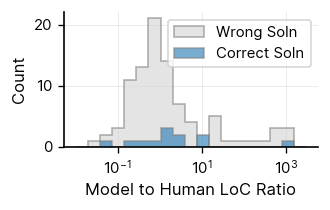

Model/Human Num Edited Lines Ratio Statistics:
Total instances: 105
Model beats human in 15/105 cases (14.3%)

Not Beaten cases:
  Mean ratio: 1.6497
  Median ratio: 0.1257
  Count: 90
  25th percentile: 0.0533   50th percentile: 0.1257   60th percentile: 0.1778

Beaten cases:
  Mean ratio: 0.3822
  Median ratio: 0.2855
  Count: 15
  25th percentile: 0.1552   50th percentile: 0.2855   60th percentile: 0.3626


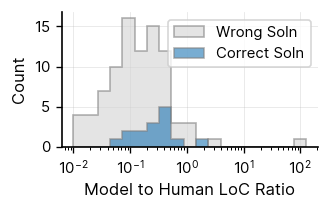

,instance_id,beat,gt_num_edited_lines,patch_num_edited_lines,num_edited_lines_ratio
0,abetlen__llama-cpp-python-218d361,False,965.0,15.1,0.015648
1,abetlen__llama-cpp-python-2bc1d97,False,915.0,10.3,0.011257
2,huggingface__datasets-5994036,True,156.0,13.3,0.085256
3,huggingface__datasets-c5464b3,False,103.0,5.1,0.049515
4,huggingface__datasets-ef3b5dd,False,493.0,11.2,0.022718
...,...,...,...,...,...
100,uploadcare__pillow-simd-6eacce9,False,474.0,44.1,0.093038
101,uploadcare__pillow-simd-7511039,False,1174.0,20.9,0.017802
102,uploadcare__pillow-simd-9e60023,False,304.0,17.1,0.056250
103,uploadcare__pillow-simd-b4045cf,False,837.0,23.1,0.027599


In [70]:
plot_loc_ratio_dist(
    analysis_df_claude, "num_edited_lines", figsize=(3.5, 3), model_name="claude"
)

plot_loc_ratio_dist(
    analysis_df_o4mini, "num_edited_lines", figsize=(3.5, 3), model_name="o4-mini"
)

#### Human-Model Agreement on File Extension

In [75]:
def analyze_patch_vs_gt(
    analysis_df,
    feature_name="extensions",
    figsize=(5, 4),
    save_path=None,
    add_title=False,
):
    import matplotlib.pyplot as plt
    from collections import Counter
    import pandas as pd

    # Ensure the feature exists in the dataset
    gt_col = f"gt_{feature_name}"
    patch_col = f"patch_{feature_name}"

    # Use raw dataframe
    grouped_df = (
        analysis_df.groupby("instance_id")
        .agg({"beat": "max", gt_col: "first", patch_col: "first"})
        .reset_index()
    )

    # Convert lists to sets for easier comparison
    grouped_df[gt_col] = grouped_df[gt_col].apply(
        lambda x: set(x) if isinstance(x, list) else x
    )
    grouped_df[patch_col] = grouped_df[patch_col].apply(
        lambda x: set(x) if isinstance(x, list) else x
    )

    # Filter out rows where either gt or patch data is empty
    grouped_df = grouped_df[grouped_df[gt_col].apply(lambda x: len(x) > 0)]
    grouped_df = grouped_df[grouped_df[patch_col].apply(lambda x: len(x) > 0)]

    # Calculate missing and extra elements
    grouped_df["missing_elements"] = grouped_df.apply(
        lambda row: row[gt_col] - row[patch_col], axis=1
    )
    grouped_df["extra_elements"] = grouped_df.apply(
        lambda row: row[patch_col] - row[gt_col], axis=1
    )

    # ---------------------------------------------------------------------------
    # 1.  Flatten counters (UNCHANGED)
    # ---------------------------------------------------------------------------
    all_missing = [
        item for sublist in grouped_df["missing_elements"] for item in sublist if item
    ]
    all_extra = [
        item for sublist in grouped_df["extra_elements"] for item in sublist if item
    ]

    missing_counter = Counter(all_missing)
    extra_counter = Counter(all_extra)

    # ---------------------------------------------------------------------------
    # 2.  Top‑5 of each list (UNCHANGED)
    # ---------------------------------------------------------------------------
    top_missing = missing_counter.most_common(5)
    top_extra = extra_counter.most_common(5)

    ignore_list = ["10", "apex", "src"]
    top_missing = [(item, cnt) for item, cnt in top_missing if item not in ignore_list]
    top_extra = [(item, cnt) for item, cnt in top_extra if item not in ignore_list]

    missing_elements = [item for item, _ in top_missing]
    missing_percent = [cnt / len(grouped_df) * 100 for _, cnt in top_missing]
    extra_elements = [item for item, _ in top_extra]
    extra_percent = [cnt / len(grouped_df) * 100 for _, cnt in top_extra]

    # ---------------------------------------------------------------------------
    # 3.  Combine for plotting (UNCHANGED logic, just clearer names)
    #     – Missing rows first, Extra rows after.
    # ---------------------------------------------------------------------------
    all_elements = extra_elements + missing_elements
    all_percentages = extra_percent + missing_percent
    all_colors = [METRICS_COLOR_MAP["Positive"]] * len(extra_elements) + [
        METRICS_COLOR_MAP["Negative"]
    ] * len(missing_elements)

    # reverse so “Missing” appears at the top (same as your original)
    all_elements.reverse()
    all_percentages.reverse()
    all_colors.reverse()

    positions = np.arange(len(all_elements))
    missing_count = len(missing_elements)  # needed for background split
    total_elements = len(all_elements)

    # ---------------------------------------------------------------------------
    # 4.  Build the figure
    # ---------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)  # same figsize you pass in

    # -- background bands --------------------------------------------------------
    ax.axhspan(
        missing_count - 0.5,  # start at first “Extra” bar
        total_elements - 0.5,  # bottom
        facecolor="#f5fff8",  # very light mint
        alpha=0.55,
        zorder=0,
    )

    ax.axhspan(
        -0.5,  # start slightly above first bar
        missing_count - 0.5,  # end of missing section
        facecolor="#fef0f0",  # very light red
        alpha=0.55,
        zorder=0,
    )

    # -- right‑hand group labels -----------------------------------------------
    mid_missing = (missing_count - 1) / 2
    mid_extra = (missing_count + total_elements - 1) / 2

    ax.text(
        0.75,
        mid_missing / total_elements,
        "Missing",
        # rotation=90,
        transform=ax.transAxes,
        va="center",
        ha="left",
        # fontsize=12,
        fontweight="bold",
    )

    ax.text(
        0.75,
        mid_extra / total_elements + 0.05,
        "Extra",
        # rotation=90,
        transform=ax.transAxes,
        va="center",
        ha="left",
        # fontsize=12,
        fontweight="bold",
    )

    bars = ax.barh(
        positions,
        all_percentages,
        align="center",
        color=all_colors,
        alpha=0.8,
        height=0.7,
    )

    # value labels (unchanged)
    for bar in bars:
        width = bar.get_width()
        if width > 1:  # show only if >1 %
            ax.text(
                width + 0.3,
                bar.get_y() + bar.get_height() / 2,
                f"{width:.1f}%",
                ha="left",
                va="center",
                # fontsize=11,
            )

    ax.set_yticks(positions)
    ax.set_yticklabels(all_elements)
    ax.set_xlabel("% of Model Patches")
    ax.set_xlim(0, 26)
    ax.grid(True, axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)
    setup_plot_style()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Saved figure to {save_path}")
    plt.show()

Saved figure to plots/patch_gt_extensions_o4-mini.png


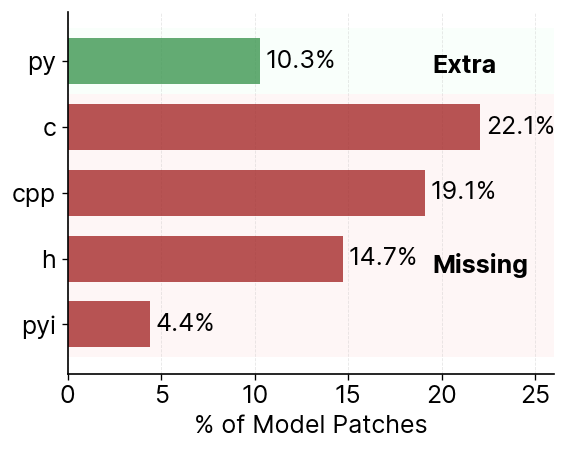

Saved figure to plots/patch_gt_extensions_claude.png


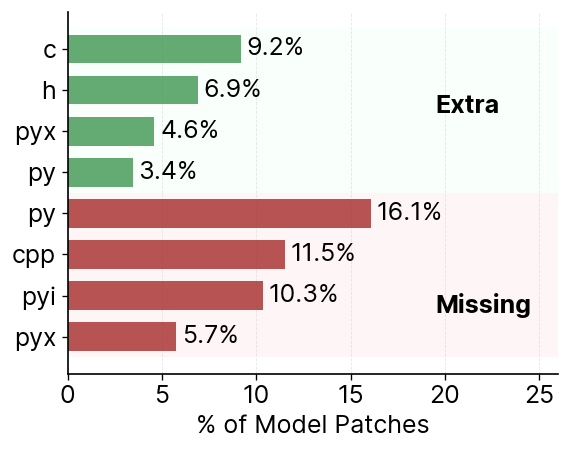

In [76]:
analyze_patch_vs_gt(
    analysis_df_o4mini,
    "extensions",
    save_path="plots/patch_gt_extensions_o4-mini.png",
    figsize=(5, 4),
)

analyze_patch_vs_gt(
    analysis_df_claude,
    "extensions",
    save_path="plots/patch_gt_extensions_claude.png",
    figsize=(5, 4),
)

Saved combined figure to plots/patch_gt_extensions_combined.png


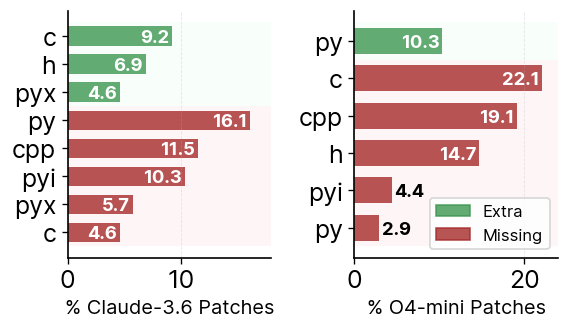

In [171]:
def analyze_patch_vs_gt_combined(
    analysis_df_list,
    model_names,
    feature_name="extensions",
    figsize=(10, 4),
    save_path=None,
):
    import matplotlib.pyplot as plt
    from collections import Counter
    import pandas as pd
    import numpy as np

    fig, axs = plt.subplots(
        1, len(analysis_df_list), figsize=figsize, sharey=False, width_ratios=[0.7, 0.7]
    )

    # Check if axs is a single axis object (in case only one dataframe is provided)
    if not isinstance(axs, np.ndarray):
        axs = [axs]

    for idx, (analysis_df, model_name, ax) in enumerate(
        zip(analysis_df_list, model_names, axs)
    ):
        # Similar data preparation as your original function
        gt_col = f"gt_{feature_name}"
        patch_col = f"patch_{feature_name}"

        # Use raw dataframe
        grouped_df = (
            analysis_df.groupby("instance_id")
            .agg({"beat": "max", gt_col: "first", patch_col: "first"})
            .reset_index()
        )

        # Convert lists to sets for easier comparison
        grouped_df[gt_col] = grouped_df[gt_col].apply(
            lambda x: set(x) if isinstance(x, list) else x
        )
        grouped_df[patch_col] = grouped_df[patch_col].apply(
            lambda x: set(x) if isinstance(x, list) else x
        )

        # Filter out rows where either gt or patch data is empty
        grouped_df = grouped_df[grouped_df[gt_col].apply(lambda x: len(x) > 0)]
        grouped_df = grouped_df[grouped_df[patch_col].apply(lambda x: len(x) > 0)]

        # Calculate missing and extra elements
        grouped_df["missing_elements"] = grouped_df.apply(
            lambda row: row[gt_col] - row[patch_col], axis=1
        )
        grouped_df["extra_elements"] = grouped_df.apply(
            lambda row: row[patch_col] - row[gt_col], axis=1
        )

        # Flatten counters
        all_missing = [
            item
            for sublist in grouped_df["missing_elements"]
            for item in sublist
            if item
        ]
        all_extra = [
            item for sublist in grouped_df["extra_elements"] for item in sublist if item
        ]

        missing_counter = Counter(all_missing)
        extra_counter = Counter(all_extra)

        # Top‑5 of each list
        top_missing = missing_counter.most_common(6)
        top_extra = extra_counter.most_common(3)

        ignore_list = ["10", "apex", "src"]
        top_missing = [
            (item, cnt) for item, cnt in top_missing if item not in ignore_list
        ]
        top_extra = [(item, cnt) for item, cnt in top_extra if item not in ignore_list]

        missing_elements = [item for item, _ in top_missing]
        missing_percent = [cnt / len(grouped_df) * 100 for _, cnt in top_missing]
        extra_elements = [item for item, _ in top_extra]
        extra_percent = [cnt / len(grouped_df) * 100 for _, cnt in top_extra]

        # Combine for plotting
        all_elements = extra_elements + missing_elements
        all_percentages = extra_percent + missing_percent
        all_colors = [METRICS_COLOR_MAP["Positive"]] * len(extra_elements) + [
            METRICS_COLOR_MAP["Negative"]
        ] * len(missing_elements)

        # reverse so "Missing" appears at the top
        all_elements.reverse()
        all_percentages.reverse()
        all_colors.reverse()

        positions = np.arange(len(all_elements))
        missing_count = len(missing_elements)
        total_elements = len(all_elements)

        # Build the subplot

        # -- background bands
        ax.axhspan(
            missing_count - 0.5,
            total_elements - 0.5,
            facecolor="#f5fff8",  # very light mint
            alpha=0.65,
            zorder=0,
        )

        ax.axhspan(
            -0.5,
            missing_count - 0.5,
            facecolor="#fef0f0",  # very light red
            alpha=0.55,
            zorder=0,
        )

        # Plot bars
        bars = ax.barh(
            positions,
            all_percentages,
            align="center",
            color=all_colors,
            alpha=0.8,
            height=0.7,
        )

        # Value labels
        for bar in bars:
            width = bar.get_width()
            # set the label right inside the bar but end of the bar
            if width > 4.5:
                ax.text(
                    width - 0.25,
                    bar.get_y() + bar.get_height() / 2 - 0.04,
                    f"{width:.1f}",
                    ha="right",
                    va="center",
                    fontsize=11,
                    color="white",
                    fontweight="bold",
                )
            else:
                # black text regular position
                ax.text(
                    width + 0.3,
                    bar.get_y() + bar.get_height() / 2 - 0.04,
                    f"{width:.1f}",
                    ha="left",
                    va="center",
                    fontsize=11,
                    fontweight="bold",
                )

        ax.set_yticks(positions)
        ax.set_yticklabels(all_elements)

        if idx == 1:
            ax.set_xlim(0, 24)
        else:
            ax.set_xlim(0, 18)

        # add x label with % model name patches
        ax.set_xlabel(f"% {model_name} Patches", fontsize=12)

        # if idx == 0 add a custom legend
        if idx == 1:
            ax.legend(
                [
                    plt.Rectangle(
                        (0, 0), 1, 1, color=METRICS_COLOR_MAP["Positive"], alpha=0.8
                    ),
                    plt.Rectangle(
                        (0, 0), 1, 1, color=METRICS_COLOR_MAP["Negative"], alpha=0.8
                    ),
                ],
                ["Extra", "Missing"],
                loc="lower right",
                fontsize=10,
            )

        ax.grid(True, axis="x", linestyle="--", alpha=0.3)
        # ax.set_title(model_name, fontsize=12)

    setup_plot_style()
    plt.tight_layout()  # Add space at the bottom for the legend

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Saved combined figure to {save_path}")

    plt.show()


analyze_patch_vs_gt_combined(
    analysis_df_list=[analysis_df_claude, analysis_df_o4mini],
    model_names=["Claude-3.6", "O4-mini"],
    feature_name="extensions",
    figsize=(5, 3),
    save_path="plots/patch_gt_extensions_combined.png",
)